# Imports


In [1]:
%reload_ext autoreload
%autoreload 2

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "analog_qec").is_dir() and (candidate / "notebook").is_dir():
            return candidate
    raise RuntimeError("Could not find the analog-qec repository root")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analog_qec.phenomenological_resource_estimate import (
    apply_plot_style,
    build_comparison_points,
    default_phenomenological_resource_estimate_config,
    default_plot_config,
    plot_phenomenological_resource_estimate,
    plot_stacked_phenomenological_resource_estimate,
)

plot_config = default_plot_config()
apply_plot_style(plot_config)

FIGURE_DIR = REPO_ROOT / "notebook" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Phenomenological resource estimate

This plot shows register failure probability $P_\mathrm{fail}=1-e^{-H}$ on the x-axis while positioning points by the cumulative register error exponent $H$ internally. The benchmark is specified by dimensionless angular analog evolution time $Jt$. Here a 25 ns interaction time means one full $2\pi$ rotation, so the physical time per unit $Jt$ is $25\,\mathrm{ns}/2\pi$. Raw and EPS use this physical analog time, while surface code and STAR use an optimistic edge-colored Trotterization of the same $Jt$.

The default y-axis values include the measurement overhead for an observable-estimation task rather than only one circuit attempt. The task is final XY energy density plus radial transverse correlations, measured in global X and global Y bases. The default shot count is computed from the bounded-estimator rule $N_\mathrm{shots/basis}=\lceil\mathrm{Var}/\epsilon^2\rceil$ with $\mathrm{Var}\le1$ and $\epsilon=10^{-2}$, giving 10,000 shots per basis and 20,000 circuit executions total. Space-only plots are unaffected by this multiplier; time and space-time plots multiply the single-shot circuit time by the task shot count. Set `comparison_config.observable_task.enabled=False` to recover single-shot/per-attempt costs.

All analog and logical-lifetime exponents use an effective transverse coherence time $T_2$ in $H=nT_\mathrm{err}/T_2$. In the raw analog case this $T_2$ is dominated by pure dephasing, so we label the swept parameter as $T_\phi$. In the EPS case pure dephasing is assumed to be removed, so the limiting value is $T_2=2T_1$ and the plotted EPS labels quote the corresponding $T_1$.

For the surface-code baseline, the single-shot time factor is circuit depth, not total T count: T gates on different edges/registers are parallelized into edge-color and synthesis-depth layers. The total T count is used only to size an optimistic magic-state factory area, with no routing overhead or factory-induced stalls. STAR is plotted as a partial-FTQC literature baseline: it keeps the same Trotterized Pauli-rotation structure as the surface-code branch, but directly implements arbitrary rotations through injected analog-rotation states instead of Clifford+T synthesis and magic-state distillation. Its plotted exponent is $H_\mathrm{STAR}=H_\mathrm{rot}+H_\mathrm{Cliff}$, with $H_\mathrm{rot}=N_\mathrm{rot}/N_\mathrm{rot,budget}$ and $N_\mathrm{rot,budget}=1/[2(2p/15)]$ matching the STAR paper's two-RUS-step average. The Clifford term uses the paper's fitted logical-round scaling for $d=3,5,7,9$ as a sensitivity estimate, and we show STAR traces for $p=5\times10^{-5}$, $p=10^{-4}$, and $p=5\times10^{-4}$. All STAR points use the same 50-site benchmark; the d=9 point has 12,960 physical qubits in the compact-block model.


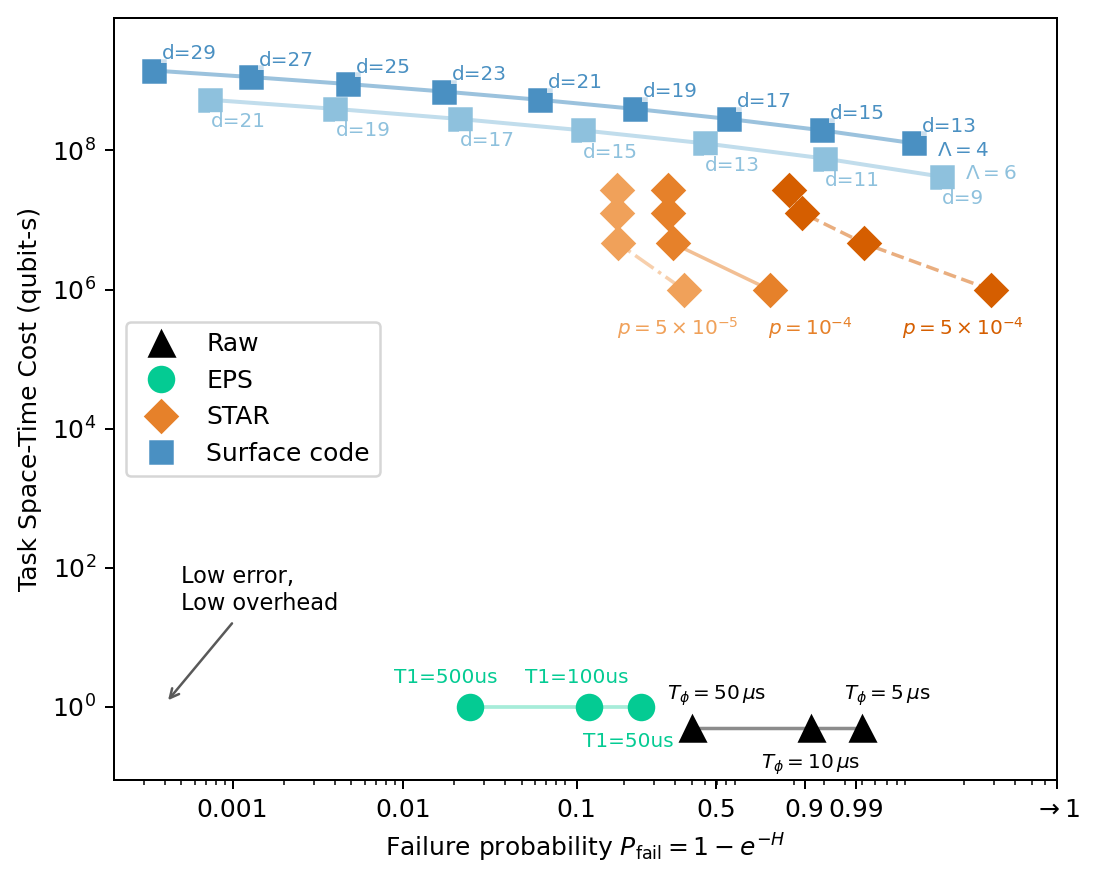

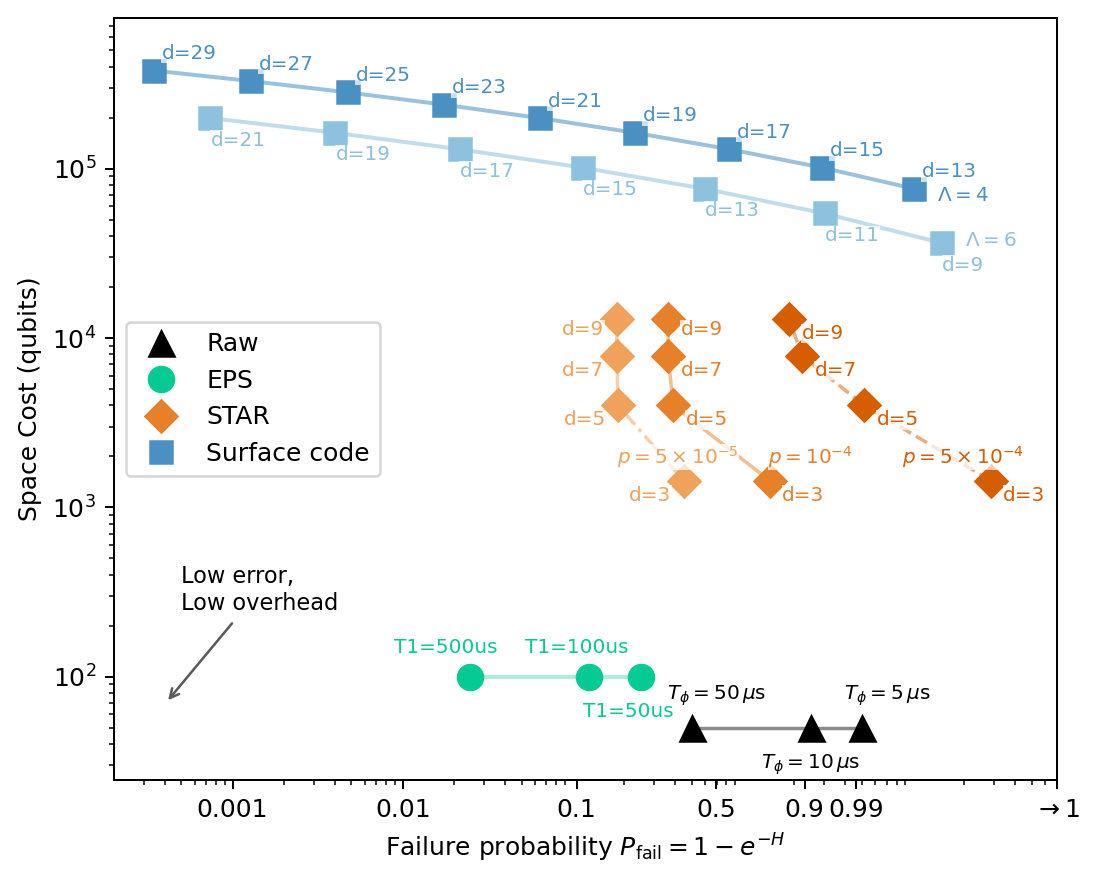

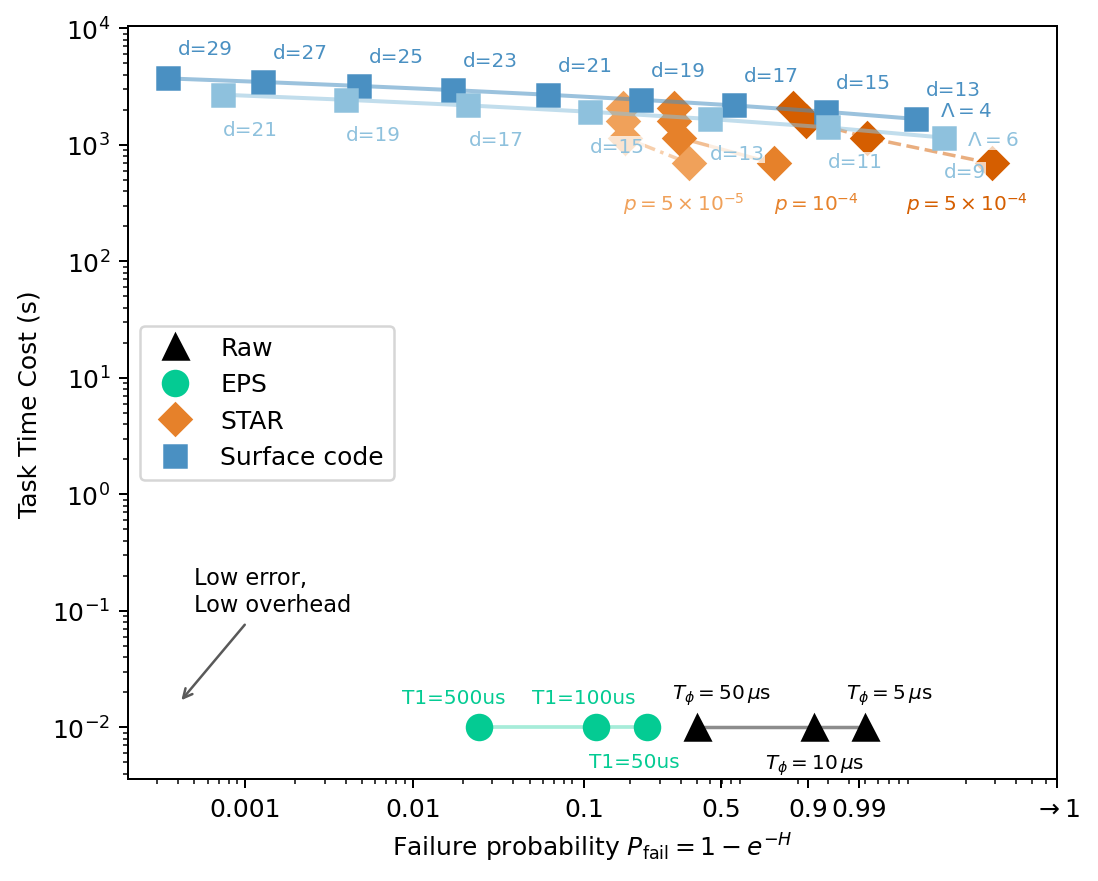

In [6]:
comparison_config = default_phenomenological_resource_estimate_config()
# Default task: Var <= 1, epsilon = 1e-2, two bases -> 20,000 shots.
# To recover single-shot/per-attempt costs, uncomment:
# comparison_config = replace(
#     comparison_config,
#     observable_task=replace(comparison_config.observable_task, enabled=False),
# )
comparison_points = build_comparison_points(comparison_config)
# len(comparison_points)

plot_config = default_plot_config()
# Optional notebook-only tweaks to config.py defaults go here.
# plot_config.raw_annotation_offsets.update({
#     r"Raw $T_\phi=5\,\mu\mathrm{s}$": (5, 8),
#     r"Raw $T_\phi=10\,\mu\mathrm{s}$": (0, -10),
#     r"Raw $T_\phi=50\,\mu\mathrm{s}$": (0, 8),
# })
# plot_config.star_p_label_offsets_by_metric["space"].update({
#     5e-5: (0, -50),
#     1e-4: (40, -50),
#     5e-4: (45, -50),
# })
# plot_config.star_p_label_offsets_by_metric["time"].update({
#     5e-5: (0, -50),
#     1e-4: (40, -50),
#     5e-4: (45, -50),
# })
# plot_config.surface_distance_label_offsets_by_metric["space"].update({
#     2: (4, 2),
#     4: (3, 3),
#     6: (0, -5),
# })
# plot_config.surface_distance_label_offsets_by_metric["time"].update({
#     2: (4, 2),
#     4: (4, 8),
#     6: (0, -10),
# })
# plot_config.lambda_label_offsets_by_metric["space"].update({
#     2: (30, 0),
#     4: (30, 1),
#     6: (30, 8),
# })
# plot_config.lambda_label_offsets_by_metric["time"].update({
#     2: (30, 0),
#     4: (30, 10),
#     6: (30, -8),
# })
apply_plot_style(plot_config)

figure_outputs = {
    "space_time": "figure_5_resource_estimation.pdf",
    "space": "figure_5_resource_estimation_space_cost.pdf",
    "time": "figure_5_resource_estimation_time_cost.pdf",
}

for y_metric, filename in figure_outputs.items():
    fig, ax = plot_phenomenological_resource_estimate(
        comparison_points,
        plot_config=plot_config,
        y_metric=y_metric,
    )
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.show()

# Use any subset of ("space_time", "space", "time") here.
stacked_y_metrics = ("space_time", "space", "time")
fig, axes = plot_stacked_phenomenological_resource_estimate(
    comparison_points,
    plot_config=plot_config,
    y_metrics=stacked_y_metrics,
)
output_path = FIGURE_DIR / "figure_5_resource_estimation_stacked.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()

# [point.as_dict() for point in comparison_points]
